# Credit Card Fraud Detection Using Machine Learning



## Problem Statement

Credit card fraud is a significant challenge for financial institutions, leading to financial loses , reduced customer trust , and increased operatinal costs.This project develops a machine learning pipeline to detect fradulent credit card transactions using historical transaction data .


This problem is important because detecting fraud early can help the company prevent losses and improve the security of its payment systems. By identifying suspicious transactions in real time, the company can take immediate action, such as blocking transactions or requesting verification from customers.

To address this problem, datas such as transaction amount, transaction time, and behavioural patterns can be collected from internal company database.
From machine learning perspective, this task is treated as a binary classification task, with the aim of determining weather a transaction is:
- 0 → Legitimate  
- 1 → Fraudulent  

The objective is to build and evaluate different machine learning models, compare their performance, and select the most effective model for detecting fraudulent transactions.



## Dataset

**Dataset Link:**  
https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud

This dataset has real transaction data and is highly imbalanced.



3. #Import libraries

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.inspection import permutation_importance

4. # Load the dataset
Here I load the dataset and inspect the first few rows to confirm that it has been imported correctly.

In [6]:
df = pd.read_csv("creditcard.csv")
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
df.shape

(284807, 31)

In [4]:
df.columns.tolist()

['Time',
 'V1',
 'V2',
 'V3',
 'V4',
 'V5',
 'V6',
 'V7',
 'V8',
 'V9',
 'V10',
 'V11',
 'V12',
 'V13',
 'V14',
 'V15',
 'V16',
 'V17',
 'V18',
 'V19',
 'V20',
 'V21',
 'V22',
 'V23',
 'V24',
 'V25',
 'V26',
 'V27',
 'V28',
 'Amount',
 'Class']

### Understanding the Dataset

This dataset contains transaction records used to detect fraudulent credit card activity. Most of the features are anonymous numerical variables named **V1 to V28**. These variables were transformed using **PCA (Principal Component Analysis)** to protect sensitive information.

The  variable in the dataset is **Class**. This section tells us if a transaction is normal or not .
- **0** = legitimate
- **1** = fraudulent

Overall, the dataset has **284,807 rows** and **31 columns**, making it a large dataset for the study analysis.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Time,284807.0,9.481386e+04,47488.145955,0.000000,54201.500000,84692.000000,139320.500000,172792.000000
V1,284807.0,1.168375e-15,1.958696,-56.407510,-0.920373,0.018109,1.315642,2.454930
V2,284807.0,3.416908e-16,1.651309,-72.715728,-0.598550,0.065486,0.803724,22.057729
V3,284807.0,-1.379537e-15,1.516255,-48.325589,-0.890365,0.179846,1.027196,9.382558
V4,284807.0,2.074095e-15,1.415869,-5.683171,-0.848640,-0.019847,0.743341,16.875344
V5,284807.0,9.604066e-16,1.380247,-113.743307,-0.691597,-0.054336,0.611926,34.801666
V6,284807.0,1.487313e-15,1.332271,-26.160506,-0.768296,-0.274187,0.398565,73.301626
V7,284807.0,-5.556467e-16,1.237094,-43.557242,-0.554076,0.040103,0.570436,120.589494
V8,284807.0,1.213481e-16,1.194353,-73.216718,-0.208630,0.022358,0.327346,20.007208
V9,284807.0,-2.406331e-15,1.098632,-13.434066,-0.643098,-0.051429,0.597139,15.594995


### Data Exploration Discussion

To better understand the dataset, I first checked its structure, size, and data types. The dataset contains 284,807 rows and 31 columns, which shows that it is quite large.

From the information output, all columns have the same number of entries, meaning no missing values were observed in the dataset. 

Looking at the statistical summary, the features (V1 to V28) appear to be centered around zero, which is expected since they were transformed using PCA. The Amount variable has a wide range, indicating that transaction values vary significantly.

Another important observation is the Class variable. The average value is very close to 0, which suggests that fraudulent transactions are very rare compared to normal ones. This confirms that the dataset is highly imbalanced.



In [7]:
print("Dataset shape:", df.shape)
print("\nMissing values:\n")
print(df.isnull().sum())

Dataset shape: (284807, 31)

Missing values:

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


In [8]:
duplicate_count = df.duplicated().sum()
print("Duplicate rows:", duplicate_count)

Duplicate rows: 1081


In [9]:
class_counts = df["Class"].value_counts().sort_index()
class_percent = df["Class"].value_counts(normalize=True).sort_index() * 100

print("Class counts:\n", class_counts)
print("\nClass percentages (%):\n", class_percent)

Class counts:
 Class
0    284315
1       492
Name: count, dtype: int64

Class percentages (%):
 Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


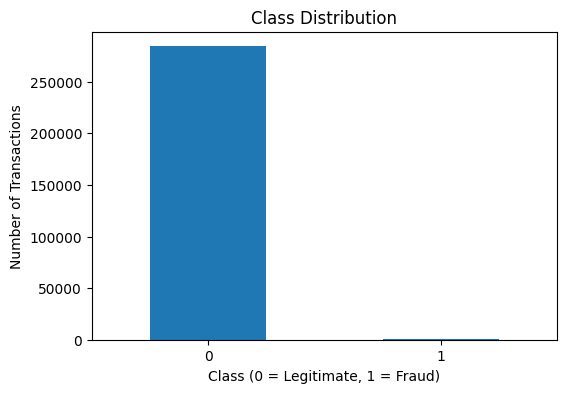

In [10]:
plt.figure(figsize=(6,4))
class_counts.plot(kind="bar")
plt.title("Class Distribution")
plt.xlabel("Class (0 = Legitimate, 1 = Fraud)")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=0)
plt.show()

### Class Distribution Analysis

From the class distribution chart, it is clear that the dataset shows a strong class  imbalance. The majority of the transactions fall under class 0 (legitimate), while very few number belongs to class 1 (fraud).

Looking at the actual numbers, there are 284,315 normal transactions and only 492 fraudulent ones. This means that fraud cases account for less than 1% of the data.

Because of this imbalance, using accuracy alone would not be a good way to evaluate a model. 
Therefore, it is more important to focus on metrics like precision, recall, and F1-score, especially recall, since correctly identifying fraud cases is the main goal.

### Data Preprocessing and Feature Engineering

Before training the models, the dataset needs to be prepared properly.

First, the input features are  separated from the target variable. After that, the dataset was divided into training and testing sets. I used stratified sampling so that both sets keep the same class distribution as the original dataset, especially because the dataset remains imbalanced.

For preprocessing, I scale the **Time** and **Amount** columns because these features are not on the same scale as the others. 
To make the process cleaner and more consistent, the preprocessing steps are included in a pipeline. 

In [7]:
X = df.drop("Class", axis=1)
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

Training set shape: (227845, 30)
Test set shape: (56962, 30)


8. # The five models we will train
To make the comparison meaningful, I will train five different models:

Logistic Regression

Decision Tree

Random Forest

K-Nearest Neighbors (KNN)

Gaussian Naive Bayes

I am using these five models because they are common, easy to compare, and suitable for a machine learning assignment 

9. # Build model pipelines

In [3]:
models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            solver="liblinear",
            class_weight="balanced",
            max_iter=1000,
            random_state=42
        ))
    ]),
    
    "Decision Tree": Pipeline([
        ("model", DecisionTreeClassifier(
            max_depth=5,
            min_samples_leaf=5,
            class_weight="balanced",
            random_state=42
        ))
    ]),
    
    "Random Forest": Pipeline([
        ("model", RandomForestClassifier(
            n_estimators=200,
            max_depth=10,
            min_samples_leaf=2,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        ))
    ]),
    
    "K-Nearest Neighbors": Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier(
            n_neighbors=7
        ))
    ]),
    
    "Gaussian Naive Bayes": Pipeline([
        ("scaler", StandardScaler()),
        ("model", GaussianNB())
    ])
}

10. # Train the five models and compare them

In [8]:
results = []

for name, pipeline in models.items():
    pipeline.fit(X_train, y_train)
    
    y_pred = pipeline.predict(X_test)
    
    if hasattr(pipeline, "predict_proba"):
        y_score = pipeline.predict_proba(X_test)[:, 1]
    else:
        y_score = None
    
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    
    if y_score is not None:
        roc_auc = roc_auc_score(y_test, y_score)
        pr_auc = average_precision_score(y_test, y_score)
    else:
        roc_auc = np.nan
        pr_auc = np.nan
    
    results.append({
        "Model": name,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
        "ROC-AUC": roc_auc,
        "PR-AUC": pr_auc
    })

results_df = pd.DataFrame(results).sort_values(by="F1-Score", ascending=False)
results_df.reset_index(drop=True, inplace=True)
results_df

,Model,Precision,Recall,F1-Score,ROC-AUC,PR-AUC
0,K-Nearest Neighbors,0.892857,0.765306,0.824176,0.948810,0.843687
1,Random Forest,0.786408,0.826531,0.805970,0.980557,0.825033
2,Logistic Regression,0.061017,0.918367,0.114431,0.972093,0.718935
3,Gaussian Naive Bayes,0.058782,0.846939,0.109934,0.963248,0.082409
4,Decision Tree,0.047383,0.877551,0.089911,0.916562,0.449784


In [9]:
results_df.style.format({
    "Precision": "{:.4f}",
    "Recall": "{:.4f}",
    "F1-Score": "{:.4f}",
    "ROC-AUC": "{:.4f}",
    "PR-AUC": "{:.4f}"
})

,Model,Precision,Recall,F1-Score,ROC-AUC,PR-AUC
0,K-Nearest Neighbors,0.8929,0.7653,0.8242,0.9488,0.8437
1,Random Forest,0.7864,0.8265,0.8060,0.9806,0.8250
2,Logistic Regression,0.0610,0.9184,0.1144,0.9721,0.7189
3,Gaussian Naive Bayes,0.0588,0.8469,0.1099,0.9632,0.0824
4,Decision Tree,0.0474,0.8776,0.0899,0.9166,0.4498


### Model Training and Evaluation

 I trained and compared five machine learning models to see which one performs best for credit card fraud detection.

Since the dataset shows its  imbalance , I did not use only accuracy as evaluation metrics. Instead, I used Precision, Recall, F1-score, ROc .



### Detailed Assessment of the Best Model

After identifying the best-performing model, It was examined futher using a classification report and a confusion matrix . This provided a a clearer view of the model perfomance on unseen test data. 

The classification report summarizes key metrics such as precision , recall and F1-score while the confusion matrix helps to show how many transactions were correctly and incorrectly classified. 

In [11]:
best_model_name = results_df.loc[0, "Model"]
best_pipeline = models[best_model_name]

print("Best model based on F1-score:", best_model_name)

Best model based on F1-score: K-Nearest Neighbors


In [12]:
best_pred = best_pipeline.predict(X_test)

print("Best Model:", best_model_name)
print("\nClassification Report:\n")
print(classification_report(y_test, best_pred, digits=4, zero_division=0))

Best Model: K-Nearest Neighbors

Classification Report:

              precision    recall  f1-score   support

           0     0.9996    0.9998    0.9997     56864
           1     0.8929    0.7653    0.8242        98

    accuracy                         0.9994     56962
   macro avg     0.9462    0.8826    0.9119     56962
weighted avg     0.9994    0.9994    0.9994     56962



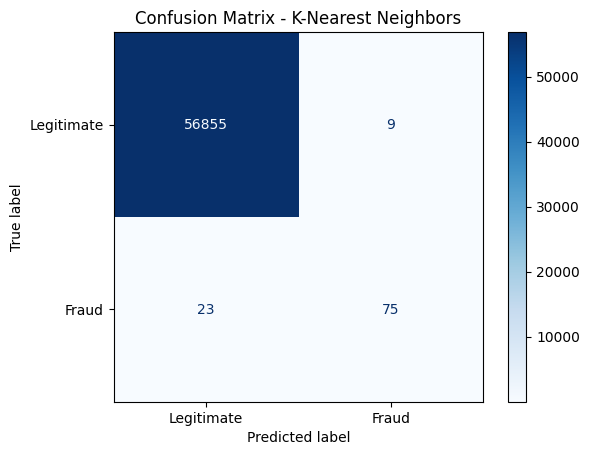

In [13]:
cm = confusion_matrix(y_test, best_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Legitimate", "Fraud"])
disp.plot(cmap="Blues")
plt.title(f"Confusion Matrix - {best_model_name}")
plt.show()

### Detailed Assessment of the Best Model

To assess the best model in more detail, I used both the classification report and the confusion matrix. These give a clearer picture of how well the model performs on unseen test data.

From the confusion matrix, the K-Nearest Neighbors model correctly classified **56,855 legitimate transactions** and **75 fraudulent transaction

13. ### Hyperparameter Tuning for the best Model

After selecting the best-performing model, which is **K-Nearest Neighbors**, the next step is to improve it by tuning its hyperparameters. Hyperparameters are the settings that control how the model works, and adjusting them can help the model perform better.


This step is important because choosing the best algorithm alone is not always enough. 

In [14]:
if best_model_name == "Logistic Regression":
    param_grid = {
        "model__C": [0.1, 1.0, 10.0]
    }

elif best_model_name == "Decision Tree":
    param_grid = {
        "model__max_depth": [3, 5, 8],
        "model__min_samples_leaf": [2, 5, 10]
    }

elif best_model_name == "Random Forest":
    param_grid = {
        "model__n_estimators": [100, 200],
        "model__max_depth": [8, 10, None],
        "model__min_samples_leaf": [1, 2, 5]
    }

elif best_model_name == "K-Nearest Neighbors":
    param_grid = {
        "model__n_neighbors": [3, 5, 7, 9],
        "model__weights": ["uniform", "distance"]
    }

Define the parameter grid

In [15]:
param_grid = {
    "model__n_neighbors": [3, 5],
    "model__weights": ["uniform"]
}

In [16]:
from sklearn.model_selection import GridSearchCV

grid = GridSearchCV(
    best_pipeline,
    param_grid=param_grid,
    scoring="f1",
    cv=3,
    n_jobs=-1
)

grid.fit(X_train, y_train)

,estimator,Pipeline(step...eighbors=7))])
,param_grid,"{'model__n_neighbors': [3, 5], 'model__weights': ['uniform']}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


In [18]:
tuned_model = grid.best_estimator_
tuned_pred = tuned_model.predict(X_test)

print("Tuned Best Model:", best_model_name)
print("\nClassification Report After Tuning:\n")
print(classification_report(y_test, tuned_pred, digits=4, zero_division=0))

Tuned Best Model: K-Nearest Neighbors

Classification Report After Tuning:

              precision    recall  f1-score   support

           0     0.9997    0.9999    0.9998     56864
           1     0.9101    0.8265    0.8663        98

    accuracy                         0.9996     56962
   macro avg     0.9549    0.9132    0.9330     56962
weighted avg     0.9995    0.9996    0.9996     56962



Confusion matrix

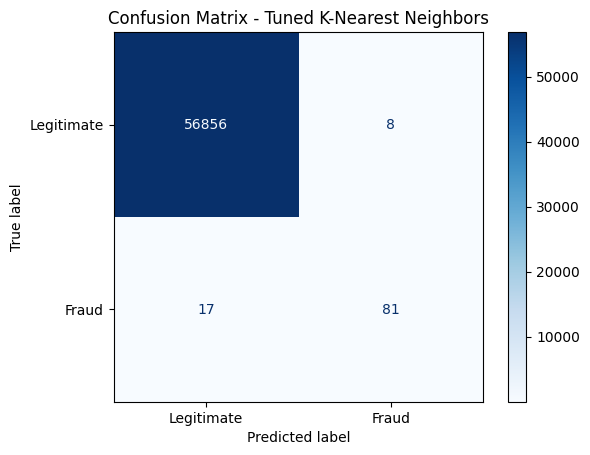

In [19]:
cm = confusion_matrix(y_test, tuned_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Legitimate", "Fraud"])
disp.plot(cmap="Blues")
plt.title(f"Confusion Matrix - Tuned {best_model_name}")
plt.show()



14. ### Most Informative Features

To understand which features are most important for the model, I use **permutation importance**. This method evaluates how much the model’s performance decreases when the values of a feature are randomly shuffled.

I chose permutation importance because it is model-independent and works well with the selected model. It provides a clear and intuitive way to identify which features contribute the most to detecting fraudulent transactions.

In [23]:
X_test_sample = X_test.sample(n=100, random_state=42)
y_test_sample = y_test.loc[X_test_sample.index]

importance = permutation_importance(
    tuned_model,
    X_test_sample,
    y_test_sample,
    n_repeats=3,
    random_state=42,
    scoring="f1"
)

In [26]:
importance_df = pd.DataFrame({
    "Feature": X_test_sample.columns,
    "Importance": importance.importances_mean
}).sort_values(by="Importance", ascending=False)

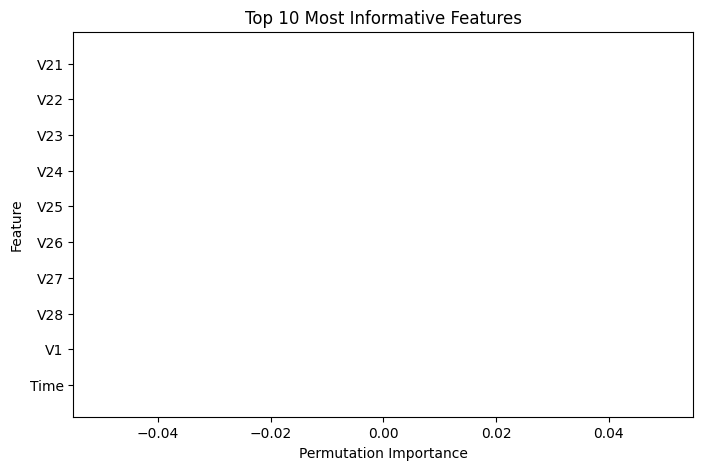

In [27]:
top_features = importance_df.head(10).sort_values(by="Importance")

plt.figure(figsize=(8, 5))
plt.barh(top_features["Feature"], top_features["Importance"])
plt.title("Top 10 Most Informative Features")
plt.xlabel("Permutation Importance")
plt.ylabel("Feature")
plt.show()

### Most Informative Features

The chart above shows the top features identified using permutation importance for the selected model. Most of the important features are anonymised variables such as V21, V22, V23, and others, which means the model is relying mainly on the transformed PCA-based features rather than on the original Time or Amount variables.




### Final Discussion

Overall, this project shows  how machine learning can be effectively applied to credit card fraud detection in a realistic setting.  I was able to identify the best-performing approach rather than relying on assumptions. 

One of the benefits  of this approach is that it helps  to detect suspicious transactions quickly and consistently. 

However, there are also important limitations. The dataset is highly imbalanced, with fraudulent transactions being very rare. This makes the task more challenging and increases the risk of the model favouring legitimate transactions. .

Another limitation is that most features are anonymised (e.g., V1, V2, etc.), which makes interpretation more difficult. 

From a business perspective, this model could help reduce financial losses by flagging suspicious transactions early and improving fraud detection efficiency. 

In terms of deployment, the model should not be used as a fully automated decision system initially. Instead, it should be implemented as a decision-support tool that assists fraud analysts. 

### Recomendation
The model should be used as a support tool for fraud analysis rather than a fully automated system.
The threshold turning could be applied to futher improve recall and reduce missed fraud cases.
Additional data sources example, customer behaviour patterns could improve model perfomance.

###  Conclusion

In summary, this study implemented a complete machine learning pipeline for detecting fraudulent credit card transactions. The dataset was explored, preprocessed, and used to train multiple classification models. 

The results indicate  that machine learning can make a meaninful contribution to fraud detection , especially when dealing with large datasets. Although issues such as class imbalance and limited interpretability exist, the final model demonstrates a practical and effective approach to identifying fraudulent activity. Overall, this project highlights the importance of model evaluation, tuning, and careful deployment in real-world applications.

## References

Vesta Corporation (2013) *Credit Card Fraud Detection Dataset: European cardholders*. Kaggle. Available at: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud (Accessed: 6 April 2026).

OpenML (2018) *Credit Card Fraud Detection Dataset*. OpenML. Available at: https://www.openml.org/d/42175 (Accessed: 6 April 2026).

Bhattacharyya, S., Jha, S., Tharakunnel, K. and Westland, J.C. (2011) ‘Data mining for credit card fraud: A comparative study’, *Decision Support Systems*, 50(3), pp. 602–613.


